# Bootstrap posterior for a multilinear fit

We have `N` data points. Crucially, *each point is not a single number* but a **distribution**:

- a distribution of `Y` values (e.g. samples from a measurement's posterior / error model),
- and a distribution for each feature `X1, X2, X3, ...` (arbitrarily many features).

The idea (a Monte-Carlo / bootstrap propagation of uncertainty) is:

1. For each of the `N` points, **draw one realisation** of `Y` and of each `X` from its distribution.
2. With those `N` drawn points, solve the linear least-squares problem
   $$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_D X_D. $$
3. Repeat `Nboot` times.

The collection of fitted parameter vectors $\beta$ is then a **posterior distribution** for the model parameters that folds in the per-point uncertainties.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def _fit_one(x, y, fit_intercept, method):
    """Fit a single drawn realisation. x: (N, D), y: (N,). Returns (D+intercept,)."""
    N, D = x.shape
    if method == 'ols':
        # ordinary least squares: regress Y on X
        A = np.column_stack([np.ones(N), x]) if fit_intercept else x
        beta, *_ = np.linalg.lstsq(A, y, rcond=None)
        return beta
    if method == 'tls':
        # total least squares / errors-in-variables: minimise the *orthogonal*
        # distance to the hyperplane instead of the vertical (Y) residual. Each
        # column is standardised first so the orthogonal metric treats an error
        # as proportional to that variable's spread, then mapped back to raw units.
        M = np.column_stack([x, y])
        mu = M.mean(0)
        sd = M.std(0)
        sd[sd == 0] = 1.0
        Z = (M - mu) / sd
        *_, Vt = np.linalg.svd(Z, full_matrices=False)
        v = Vt[-1] / sd                      # normal to best-fit hyperplane (raw scale)
        slopes = -v[:D] / v[D]
        intercept = mu[D] - slopes @ mu[:D]
        return np.concatenate([[intercept], slopes]) if fit_intercept else slopes
    raise ValueError(f"unknown method {method!r} (use 'ols' or 'tls')")


def bootstrap_multilinear_fit(y_dists, x_dists, n_boot=10000, fit_intercept=True,
                              method='ols', rng=None):
    """Bootstrap posterior for a multilinear model Y = b0 + b1*X1 + b2*X2 + ...

    Each of the N data points carries a *distribution* (a set of samples) for
    its Y value and for each of its D features. On every bootstrap iteration we
    draw one realisation from each point's distributions, assemble the N drawn
    points, and fit the linear model. The collection of fitted parameter vectors
    over all iterations forms the posterior, folding in the per-point errors.

    Parameters
    ----------
    y_dists : array_like, shape (N, Sy)
        N distributions of the response. Row i holds Sy samples of Y_i.
    x_dists : array_like, shape (N, D, Sx)
        N distributions for each of D features. x_dists[i, j] holds Sx samples
        of feature j for point i. A plain (N, D) array of point estimates also
        works: it is treated as Sx = 1.
    n_boot : int
        Number of bootstrap iterations.
    fit_intercept : bool
        If True a constant column is added so beta[0] is the intercept.
    method : {'ols', 'tls'}
        'ols' regresses Y on X (ordinary least squares). It propagates the input
        uncertainties into *honest* parameter error bars but, like any Y-on-X
        regression, attenuates slopes toward zero when X carries error
        (regression dilution). 'tls' uses total least squares (errors-in-
        variables): it minimises the orthogonal distance and largely removes
        that slope bias, at the cost of assuming comparable X/Y error scales.
    rng : int, np.random.Generator or None
        Source of randomness (anything np.random.default_rng accepts).

    Returns
    -------
    posterior : ndarray, shape (n_boot, D + fit_intercept)
        Each row is one fitted parameter vector. Column 0 is the intercept when
        fit_intercept is True, followed by the slope of each feature.
    """
    rng = np.random.default_rng(rng)

    y_dists = np.asarray(y_dists, dtype=float)
    x_dists = np.asarray(x_dists, dtype=float)
    if x_dists.ndim == 2:                 # (N, D) point estimates -> (N, D, 1)
        x_dists = x_dists[:, :, None]

    N, Sy = y_dists.shape
    Nx, D, Sx = x_dists.shape
    if Nx != N:
        raise ValueError(f"Y has {N} points but X has {Nx}.")

    n_params = D + (1 if fit_intercept else 0)
    posterior = np.empty((n_boot, n_params))

    point_idx = np.arange(N)
    feat_idx = np.arange(D)
    for b in range(n_boot):
        # draw one sample index per point, independently for Y and each X
        yi = rng.integers(Sy, size=N)
        y = y_dists[point_idx, yi]                                # (N,)

        xi = rng.integers(Sx, size=(N, D))
        x = x_dists[point_idx[:, None], feat_idx[None, :], xi]    # (N, D)

        posterior[b] = _fit_one(x, y, fit_intercept, method)

    return posterior

## Showcase 1 — a single feature, and *why the bootstrap matters*

We invent `N` points on a line `y = a + b*x`. Realistic measurement model: for
each point we get **one noisy observation** plus an error model, i.e. a
*distribution* centred on that noisy value, in both `x` and `y`.

We then compare three ways to estimate `(a, b)`:

1. **medians + Y error bars** — the everyday approach: collapse each point to its
   median, fit a straight line weighting by the `Y` error bar, *ignore the `X`
   errors*. Parameter error bars come from the fit covariance.
2. **bootstrap OLS** — `bootstrap_multilinear_fit(..., method='ols')`.
3. **bootstrap TLS** — `bootstrap_multilinear_fit(..., method='tls')`,
   total least squares.

Two effects to watch:

- **Precision.** The medians+Y-errors fit reports parameter error bars that are
  **too small**, because it never propagates the `X` scatter (and treats each
  median as exact). The bootstrap propagates everything, giving honest, wider
  error bars.
- **Bias.** Ignoring `X` errors **attenuates the slope** (regression dilution) —
  fits come out *too shallow*. Note an OLS bootstrap still has this bias (it is
  still a Y-on-X regression); only the errors-in-variables `tls` fit removes it.

In [2]:
def weighted_line_fit(x, y, sy):
    """Standard weighted least-squares straight line y = a + b*x using only the
    Y error bars `sy`. Returns (params, param_sigma); param_sigma is the error
    bar a 'medians + Y errorbars' analysis would *report*. X errors are ignored,
    as is common practice."""
    A = np.column_stack([np.ones_like(x), x])
    W = 1.0 / sy**2
    cov = np.linalg.inv(A.T @ (A * W[:, None]))
    beta = cov @ (A.T @ (W * y))
    return beta, np.sqrt(np.diag(cov))


rng = np.random.default_rng(0)

N = 30
true_a, true_b = 2.0, 1.5

# latent (true) positions on the line
xi = rng.uniform(0, 10, size=N)
eta = true_a + true_b * xi

# realistic measurement model: ONE noisy observation per point, plus an error
# model (a distribution of width sigma) centred on that noisy observation.
Sx = Sy = 300
sigma_x, sigma_y = 1.2, 1.5
x_obs = xi + rng.normal(0, sigma_x, size=N)
y_obs = eta + rng.normal(0, sigma_y, size=N)

x_dists = rng.normal(x_obs[:, None, None], sigma_x, size=(N, 1, Sx))   # (N, 1, Sx)
y_dists = rng.normal(y_obs[:, None],       sigma_y, size=(N, Sy))      # (N, Sy)

# per-point summaries
x_med = np.median(x_dists[:, 0, :], axis=1)
y_med = np.median(y_dists, axis=1)
x_err = np.std(x_dists[:, 0, :], axis=1)
y_err = np.std(y_dists, axis=1)

# --- three estimators ------------------------------------------------------
beta_wls, sig_wls = weighted_line_fit(x_med, y_med, y_err)              # medians + Y errbars
post_ols = bootstrap_multilinear_fit(y_dists, x_dists, n_boot=5000, method='ols', rng=1)
post_tls = bootstrap_multilinear_fit(y_dists, x_dists, n_boot=5000, method='tls', rng=1)


def row(name, a, sa, b, sb):
    print(f"{name:<22s} a = {a:5.2f} +/- {sa:4.2f}     b = {b:6.3f} +/- {sb:5.3f}")

print(f"truth:                 a =  2.00              b =  1.500\n")
row('medians + Y errbars', beta_wls[0], sig_wls[0], beta_wls[1], sig_wls[1])
row('bootstrap OLS', post_ols[:, 0].mean(), post_ols[:, 0].std(),
    post_ols[:, 1].mean(), post_ols[:, 1].std())
row('bootstrap TLS', post_tls[:, 0].mean(), post_tls[:, 0].std(),
    post_tls[:, 1].mean(), post_tls[:, 1].std())

truth:                 a =  2.00              b =  1.500

medians + Y errbars    a =  2.64 +/- 0.52     b =  1.344 +/- 0.080
bootstrap OLS          a =  3.24 +/- 0.74     b =  1.239 +/- 0.112
bootstrap TLS          a =  1.78 +/- 0.79     b =  1.496 +/- 0.119


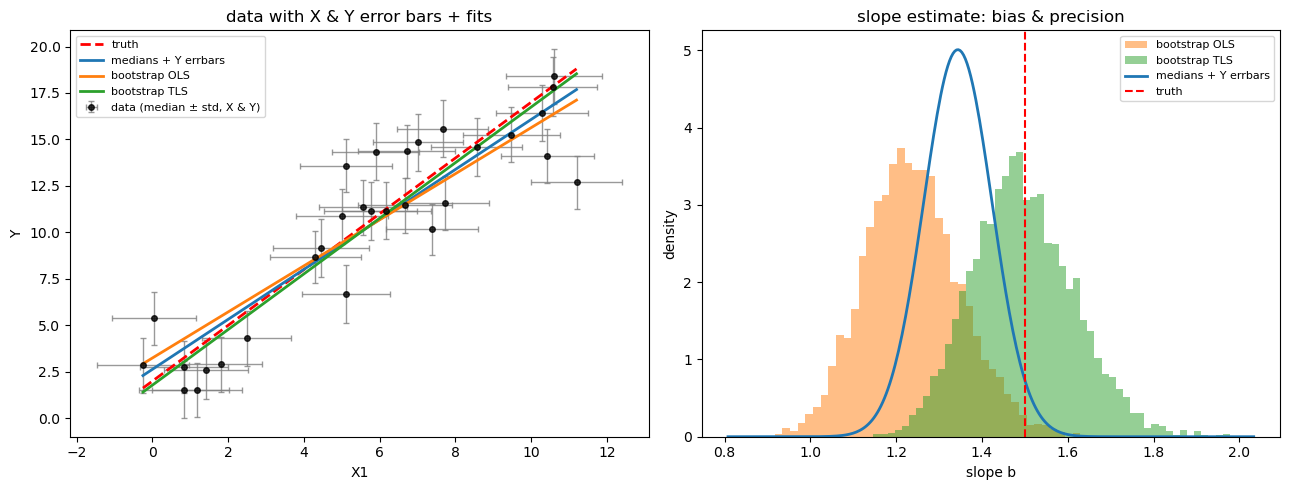

reported slope error bar:   medians+Yerr 0.080   |   bootstrap OLS 0.112   |   bootstrap TLS 0.119
the medians+Y-errbars error bar is the narrowest -- but is it honest? (next cell)


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# left: data with BOTH X and Y error bars, plus the three fitted lines
ax1.errorbar(x_med, y_med, xerr=x_err, yerr=y_err, fmt='o', ms=4, color='k',
             ecolor='gray', elinewidth=1, capsize=2, alpha=0.8,
             label='data (median ± std, X & Y)')
xx = np.array([x_med.min(), x_med.max()])
ax1.plot(xx, true_a + true_b * xx, 'r--', lw=2, label='truth')
ax1.plot(xx, beta_wls[0] + beta_wls[1] * xx, color='C0', lw=2, label='medians + Y errbars')
ax1.plot(xx, post_ols[:, 0].mean() + post_ols[:, 1].mean() * xx, color='C1', lw=2, label='bootstrap OLS')
ax1.plot(xx, post_tls[:, 0].mean() + post_tls[:, 1].mean() * xx, color='C2', lw=2, label='bootstrap TLS')
ax1.set(xlabel='X1', ylabel='Y', title='data with X & Y error bars + fits')
ax1.legend(fontsize=8)

# right: the slope estimate from each method, on the same axis
ax2.hist(post_ols[:, 1], bins=50, density=True, alpha=0.5, color='C1', label='bootstrap OLS')
ax2.hist(post_tls[:, 1], bins=50, density=True, alpha=0.5, color='C2', label='bootstrap TLS')
bb = np.linspace(*ax2.get_xlim(), 300)
gauss = np.exp(-0.5 * ((bb - beta_wls[1]) / sig_wls[1])**2) / (sig_wls[1] * np.sqrt(2 * np.pi))
ax2.plot(bb, gauss, color='C0', lw=2, label='medians + Y errbars')
ax2.axvline(true_b, color='r', ls='--', label='truth')
ax2.set(xlabel='slope b', ylabel='density', title='slope estimate: bias & precision')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"reported slope error bar:   medians+Yerr {sig_wls[1]:.3f}   |   "
      f"bootstrap OLS {post_ols[:,1].std():.3f}   |   bootstrap TLS {post_tls[:,1].std():.3f}")
print("the medians+Y-errbars error bar is the narrowest -- but is it honest? (next cell)")

In [4]:
# Which error bar is HONEST? The only ground truth for "precision" is the actual
# run-to-run scatter of an estimator over many independent mock datasets. We
# generate R fresh datasets and compare each method's *reported* slope error to
# the *true* scatter of its slope estimates.
R = 120
slopes = {'medians + Y errbars': [], 'bootstrap OLS': [], 'bootstrap TLS': []}
reports = {'medians + Y errbars': [], 'bootstrap OLS': [], 'bootstrap TLS': []}

for r in range(R):
    g = np.random.default_rng(10_000 + r)
    xi_r = g.uniform(0, 10, N)
    eta_r = true_a + true_b * xi_r
    xo = xi_r + g.normal(0, sigma_x, N)
    yo = eta_r + g.normal(0, sigma_y, N)
    xd = g.normal(xo[:, None, None], sigma_x, size=(N, 1, Sx))
    yd = g.normal(yo[:, None], sigma_y, size=(N, Sy))

    bw, sw = weighted_line_fit(np.median(xd[:, 0], 1), np.median(yd, 1), np.std(yd, 1))
    slopes['medians + Y errbars'].append(bw[1]); reports['medians + Y errbars'].append(sw[1])

    po = bootstrap_multilinear_fit(yd, xd, n_boot=400, method='ols', rng=r)
    slopes['bootstrap OLS'].append(po[:, 1].mean()); reports['bootstrap OLS'].append(po[:, 1].std())

    pt = bootstrap_multilinear_fit(yd, xd, n_boot=400, method='tls', rng=r)
    slopes['bootstrap TLS'].append(pt[:, 1].mean()); reports['bootstrap TLS'].append(pt[:, 1].std())

print(f"truth slope b = {true_b}\n")
print(f"{'method':<22s} {'mean b':>7s} {'bias':>7s} {'true scatter':>13s} {'reported err':>13s}   verdict")
for k in slopes:
    mb = np.mean(slopes[k]); ts = np.std(slopes[k]); rr = np.mean(reports[k])
    verdict = 'honest' if 0.75 < rr / ts < 1.33 else ('TOO SMALL' if rr < ts else 'too large')
    print(f"{k:<22s} {mb:7.3f} {mb-true_b:+7.3f} {ts:13.3f} {rr:13.3f}   {verdict}")

truth slope b = 1.5

method                  mean b    bias  true scatter  reported err   verdict
medians + Y errbars      1.283  -0.217         0.142         0.090   TOO SMALL
bootstrap OLS            1.122  -0.378         0.116         0.121   honest
bootstrap TLS            1.453  -0.047         0.124         0.127   honest


**Takeaway from Showcase 1.**

- The **medians + Y-errorbars** fit is *overconfident*: its reported error bar
  is much smaller than the slope's actual run-to-run scatter, because it never
  propagates the `X` errors and pretends each median is exact. It is also
  **biased shallow** (regression dilution from ignoring the `X` errors).
- The **bootstrap OLS** delivers *honest* error bars (reported ≈ true scatter),
  but still inherits the shallow-slope bias — it is still a Y-on-X regression.
- The **bootstrap TLS** delivers honest error bars **and** removes the slope
  bias by treating `X` and `Y` errors symmetrically (errors-in-variables).

So: use the bootstrap for trustworthy error bars; use `method='tls'` when `X`
errors are large enough to bias the slope.

## Showcase 2 — arbitrary number of features

Now `D = 3` features. The function is dimension-agnostic, so nothing about the
call changes — only the shape of `x_dists`. We recover the full posterior and
draw a small corner plot.

In [5]:
rng = np.random.default_rng(42)

N = 60
D = 3
true_beta = np.array([0.5, 2.0, -1.0, 0.7])   # [intercept, b1, b2, b3]

x_true = rng.uniform(-2, 2, size=(N, D))
y_true = true_beta[0] + x_true @ true_beta[1:]

Sx = Sy = 150
sigma_x, sigma_y = 0.25, 0.8

x_dists = rng.normal(x_true[:, :, None], sigma_x, size=(N, D, Sx))
y_dists = rng.normal(y_true[:, None],    sigma_y, size=(N, Sy))

posterior = bootstrap_multilinear_fit(y_dists, x_dists, n_boot=8000, rng=7)

names = ['intercept', 'b1', 'b2', 'b3']
print(f'{"param":>10s}  {"median":>8s}  {"-1sig":>7s}  {"+1sig":>7s}   truth')
for i, name in enumerate(names):
    lo, med, hi = np.percentile(posterior[:, i], [16, 50, 84])
    print(f'{name:>10s}  {med:8.3f}  {med-lo:7.3f}  {hi-med:7.3f}   {true_beta[i]:+.2f}')

     param    median    -1sig    +1sig   truth
 intercept     0.500    0.127    0.126   +0.50
        b1     1.916    0.117    0.121   +2.00
        b2    -0.974    0.101    0.099   -1.00
        b3     0.669    0.114    0.112   +0.70


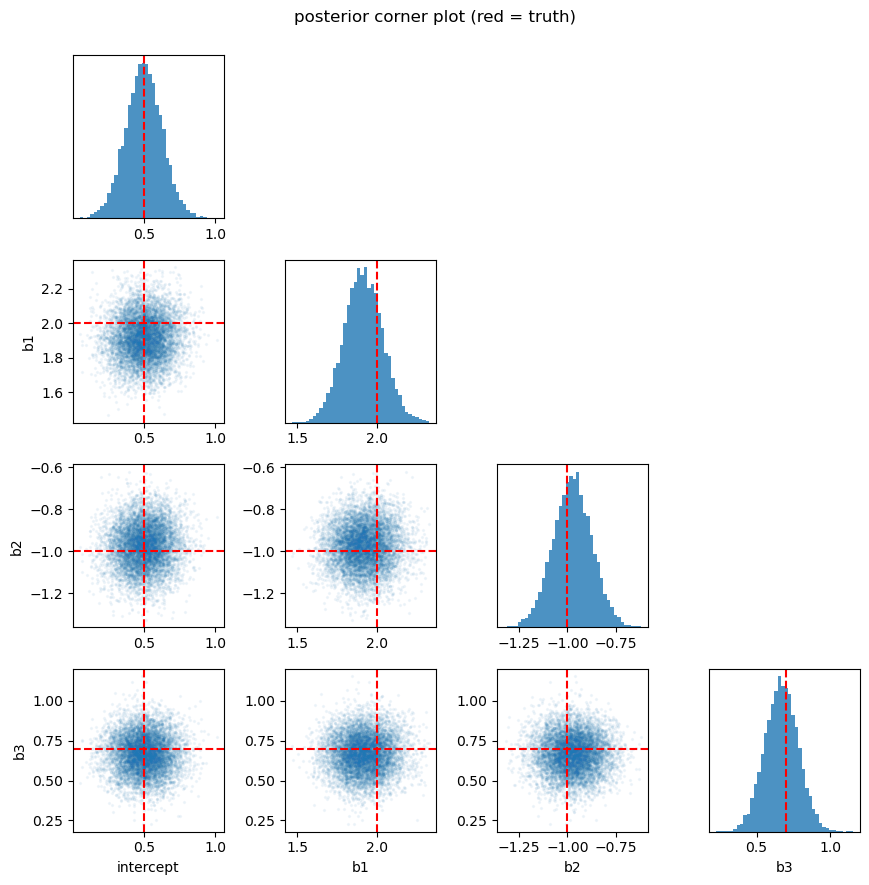

In [6]:
# minimal corner plot (no external dependencies)
P = posterior.shape[1]
fig, axes = plt.subplots(P, P, figsize=(2.2 * P, 2.2 * P))
for i in range(P):
    for j in range(P):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        if i == j:
            ax.hist(posterior[:, i], bins=40, color='C0', alpha=0.8)
            ax.axvline(true_beta[i], color='r', ls='--')
            ax.set_yticks([])
        else:
            ax.scatter(posterior[:, j], posterior[:, i], s=2, alpha=0.05, color='C0')
            ax.axvline(true_beta[j], color='r', ls='--')
            ax.axhline(true_beta[i], color='r', ls='--')
        if i == P - 1:
            ax.set_xlabel(names[j])
        if j == 0 and i > 0:
            ax.set_ylabel(names[i])
fig.suptitle('posterior corner plot (red = truth)', y=1.0)
plt.tight_layout()
plt.show()

## Showcase 3 — non-Gaussian (skewed / heavy-tailed) distributions

Real per-object distributions are often **skewed** (fluxes, masses, ages, photo-z
posteriors…). Two things then break the everyday "median ± symmetric error bar"
recipe:

- the **median ≠ the mean**, so collapsing each point to its median shifts it and
  biases the fit, and
- a single symmetric error bar cannot describe an **asymmetric** uncertainty.

The bootstrap sidesteps both — it never summarises a point, it just draws from the
full set of samples. Below, each point's `Y` distribution is strongly
right-skewed (a *zero-mean* lognormal, so the mean stays on the line while the
median sits below it); `X` is kept mildly and symmetrically noisy to isolate the
non-Gaussian-`Y` effect.

In [7]:
def skewness(a, axis=None):
    """Plain Fisher skewness, so we don't depend on scipy."""
    a = np.asarray(a, dtype=float)
    m = a.mean(axis, keepdims=True)
    s = a.std(axis, keepdims=True)
    return (((a - m) / s)**3).mean(axis)


rng = np.random.default_rng(7)
Ng = 40
true_a3, true_b3 = 1.0, 0.8
xi3 = rng.uniform(0, 12, size=Ng)
eta3 = true_a3 + true_b3 * xi3

S = 500
# strongly right-skewed Y errors: a zero-MEAN lognormal, so the *mean* stays on
# the line while the per-point median sits below it.
s_skew = 0.8
ln = rng.lognormal(0.0, s_skew, size=(Ng, S)) - np.exp(s_skew**2 / 2)   # mean 0, right-skewed
y_dists3 = eta3[:, None] + ln

# X kept mildly & symmetrically noisy, to isolate the non-Gaussian-Y effect
sigma_x3 = 0.3
x_dists3 = rng.normal(xi3[:, None, None], sigma_x3, size=(Ng, 1, S))

# per-point summaries: medians and ASYMMETRIC 16/50/84 Y intervals
y_lo, y_med3, y_hi = np.percentile(y_dists3, [16, 50, 84], axis=1)
x_med3 = np.median(x_dists3[:, 0, :], axis=1)
x_err3 = np.std(x_dists3[:, 0, :], axis=1)
y_std3 = np.std(y_dists3, axis=1)

# naive: medians + symmetric Y std error bars  vs  bootstrap over full samples
beta_wls3, sig_wls3 = weighted_line_fit(x_med3, y_med3, y_std3)
post3 = bootstrap_multilinear_fit(y_dists3, x_dists3, n_boot=6000, method='ols', rng=2)

print(f"mean per-point Y skewness: {np.mean(skewness(y_dists3, axis=1)):+.2f}   (0 = Gaussian)")
print(f"truth: a = {true_a3}, b = {true_b3}\n")
print(f"{'param':<7s} {'medians + Y errbars (symmetric)':<32s} {'bootstrap (median +up/-dn)':<28s}")
for j, name in enumerate(['a', 'b']):
    lo, md, hi = np.percentile(post3[:, j], [16, 50, 84])
    left = f"{beta_wls3[j]:6.3f} +/- {sig_wls3[j]:.3f}"
    right = f"{md:6.3f}  +{hi-md:.3f} / -{md-lo:.3f}"
    print(f"{name:<7s} {left:<32s} {right:<28s}")
print(f"\nThe median-summary intercept is pulled below the truth ({true_a3}); the "
      f"bootstrap, using the full samples, stays on it.")

mean per-point Y skewness: +3.12   (0 = Gaussian)
truth: a = 1.0, b = 0.8

param   medians + Y errbars (symmetric)  bootstrap (median +up/-dn)  
a        0.612 +/- 0.374                  0.975  +0.402 / -0.324     
b        0.801 +/- 0.056                  0.796  +0.054 / -0.056     

The median-summary intercept is pulled below the truth (1.0); the bootstrap, using the full samples, stays on it.


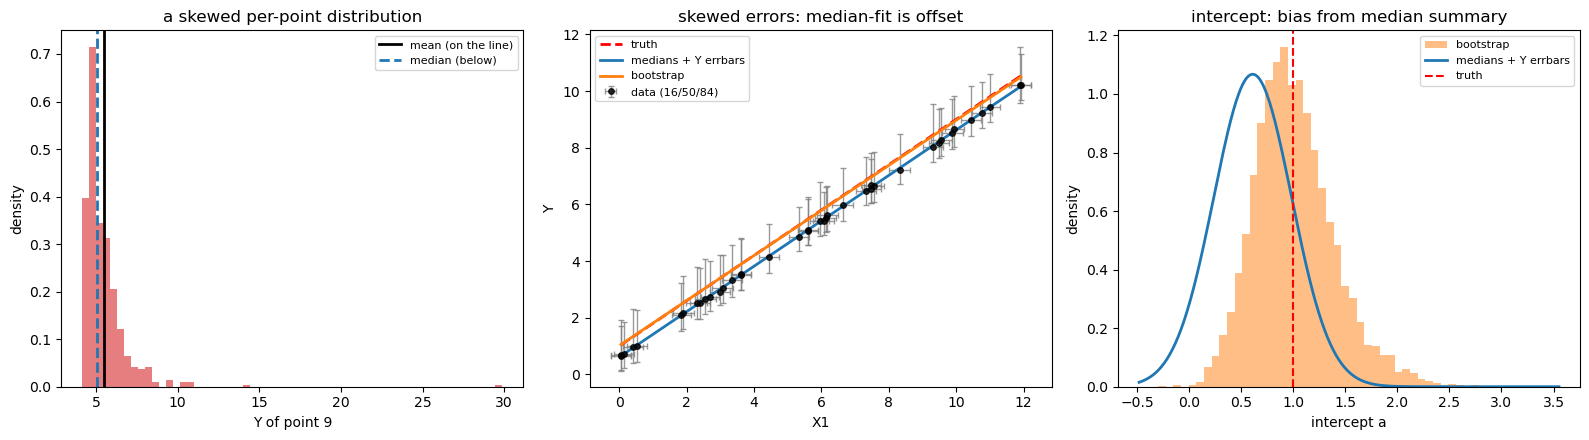

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (A) one strongly-skewed per-point Y distribution
k = int(np.argmax(np.abs(skewness(y_dists3, axis=1))))
axA = axes[0]
axA.hist(y_dists3[k], bins=60, density=True, color='C3', alpha=0.6)
axA.axvline(np.mean(y_dists3[k]), color='k', lw=2, label='mean (on the line)')
axA.axvline(np.median(y_dists3[k]), color='C0', ls='--', lw=2, label='median (below)')
axA.set(xlabel=f'Y of point {k}', ylabel='density', title='a skewed per-point distribution')
axA.legend(fontsize=8)

# (B) data with ASYMMETRIC Y error bars (16/50/84) + the two fits
axB = axes[1]
yerr_asym = np.vstack([y_med3 - y_lo, y_hi - y_med3])
axB.errorbar(x_med3, y_med3, xerr=x_err3, yerr=yerr_asym, fmt='o', ms=4, color='k',
             ecolor='gray', elinewidth=1, capsize=2, alpha=0.8, label='data (16/50/84)')
xx3 = np.array([x_med3.min(), x_med3.max()])
axB.plot(xx3, true_a3 + true_b3 * xx3, 'r--', lw=2, label='truth')
axB.plot(xx3, beta_wls3[0] + beta_wls3[1] * xx3, color='C0', lw=2, label='medians + Y errbars')
axB.plot(xx3, post3[:, 0].mean() + post3[:, 1].mean() * xx3, color='C1', lw=2, label='bootstrap')
axB.set(xlabel='X1', ylabel='Y', title='skewed errors: median-fit is offset')
axB.legend(fontsize=8)

# (C) intercept estimate: bootstrap vs the symmetric median+errorbar Gaussian
axC = axes[2]
axC.hist(post3[:, 0], bins=50, density=True, color='C1', alpha=0.5, label='bootstrap')
bb = np.linspace(*axC.get_xlim(), 300)
axC.plot(bb, np.exp(-0.5 * ((bb - beta_wls3[0]) / sig_wls3[0])**2) / (sig_wls3[0] * np.sqrt(2 * np.pi)),
         color='C0', lw=2, label='medians + Y errbars')
axC.axvline(true_a3, color='r', ls='--', label='truth')
axC.set(xlabel='intercept a', ylabel='density', title='intercept: bias from median summary')
axC.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Notes & possible extensions

- **Precision (the headline).** Collapsing each point to `median ± Y-errorbar`
  and fitting reports parameter error bars that are **too small** — it never
  propagates the `X` scatter and treats each median as exact. The bootstrap
  propagates the full per-point distributions, so its error bars match the true
  run-to-run scatter (Showcase 1's repeated-mock check).
- **Slope bias.** Ignoring `X` errors attenuates slopes toward zero (regression
  dilution). An **OLS** bootstrap gives honest error bars but keeps this bias;
  use `method='tls'` (total least squares / errors-in-variables) to remove it
  when `X` errors are comparable to or larger than the `Y` errors.
- **Non-Gaussian distributions.** For skewed/heavy-tailed per-point posteriors
  the median ≠ the mean and a symmetric error bar is meaningless. The bootstrap
  uses the raw samples directly and returns an asymmetric, honest posterior
  (Showcase 3); summarise it with percentiles, not a single ±.
- **Plain point estimates** still work: pass `x_dists` as `(N, D)` and `y_dists`
  as `(N, 1)`; the posterior collapses to the ordinary least-squares solution.
- **Correlated features within a point**: here each `X` sample is drawn
  independently. For jointly-distributed features, store joint samples and index
  them with a *single* random index per point (change `xi` to shape `(N,)`).
- **Resampling the set of points** (classic data bootstrap) can be layered on by
  also drawing `N` point indices with replacement each iteration.
- **Non-linear `f`**: swap the fit in `_fit_one` for `scipy.optimize.curve_fit`;
  the draw-then-fit-then-collect structure is identical.